# Week 1 Matplotlib 可视化练习

- **作者**：邓涵丹
- **日期**：2026-07-26
- **来源**：《实验室新生暑期居家集训学习计划》Week 1 → Matplotlib 可视化
- **适用周次**：Week 1
- **分类**：Matplotlib
- **关键词**：训练曲线、混淆矩阵、ROC、t-SNE、柱状图
- **运行环境**：Python 3.10+、NumPy、Matplotlib、scikit-learn

## 学习目标

1. 画出实验中常见的五类图表：训练曲线、混淆矩阵、性能对比柱状图、ROC 曲线和 t-SNE 特征空间可视化。
2. 为图表补充标题、坐标轴、图例和必要说明。
3. 掌握将图片保存为 PDF/PNG 报告素材的基本方式。


## 1. 训练 Loss / Accuracy 折线图

训练曲线是监控模型收敛状态的标准工具。Loss 下降、Accuracy 上升表示模型在学习；若验证集曲线恶化，则可能出现过拟合。本例使用模拟的 epoch 数据绘制双轴图。

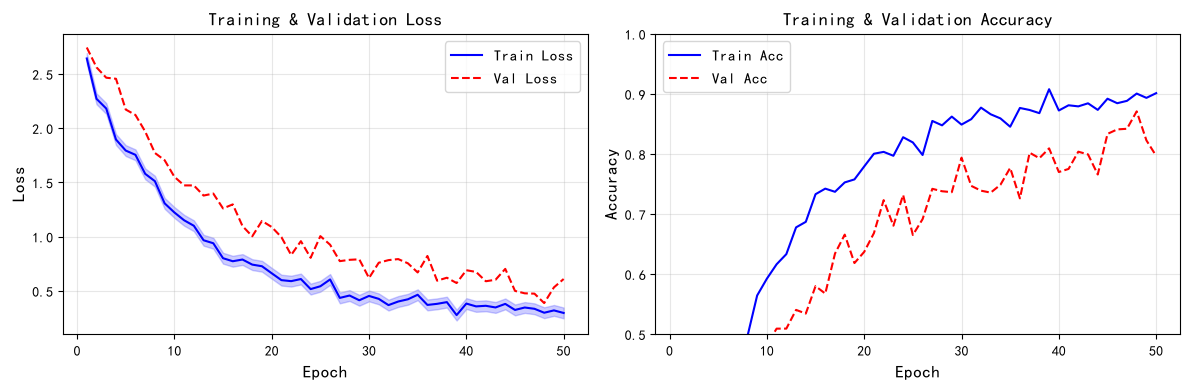

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

%matplotlib inline
# 设置字体（中文环境）
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

epochs = np.arange(1, 51)
train_loss = 2.5 * np.exp(-0.1 * epochs) + 0.3 + 0.05 * np.random.randn(50)
val_loss   = 2.5 * np.exp(-0.08 * epochs) + 0.5 + 0.08 * np.random.randn(50)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左图：Loss 曲线
axes[0].plot(epochs, train_loss, 'b-', linewidth=1.5, label='Train Loss')
axes[0].plot(epochs, val_loss,   'r--', linewidth=1.5, label='Val Loss')
axes[0].fill_between(epochs, train_loss-0.05, train_loss+0.05, alpha=0.2, color='blue')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# 右图：Accuracy 曲线
train_acc = 1 - train_loss / 3
val_acc   = 1 - val_loss / 3
axes[1].plot(epochs, train_acc, 'b-', label='Train Acc')
axes[1].plot(epochs, val_acc,   'r--', label='Val Acc')
axes[1].set_ylim(0.5, 1.0)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training & Validation Accuracy', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curve.pdf', dpi=300, bbox_inches='tight')  # 保存为PDF（论文质量）
plt.show()

## 2. 混淆矩阵热力图

混淆矩阵用于分析分类错误的具体分布。对角线数值越高说明分类越准确，非对角线则反映误判情况。本图用颜色深浅和数值标注直观展示。

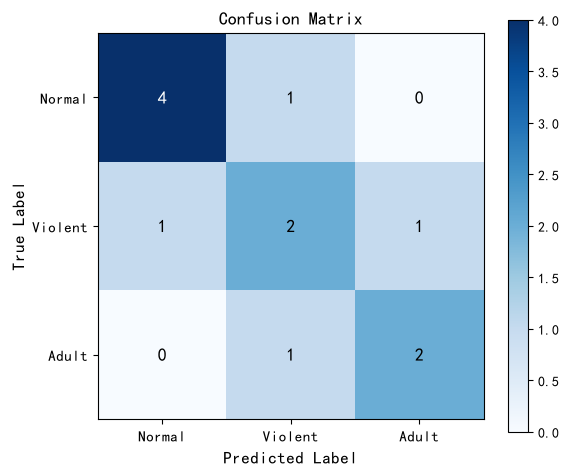

In [5]:
from sklearn.metrics import confusion_matrix

y_true = [0, 1, 2, 0, 1, 2, 0, 1, 2, 0, 1, 0]
y_pred = [0, 2, 2, 0, 0, 2, 0, 1, 1, 0, 1, 1]
cm = confusion_matrix(y_true, y_pred)
labels = ['Normal', 'Violent', 'Adult']

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im)
ax.set_xticks(range(len(labels))), ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=13)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrix.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 3. 模型性能对比柱状图

柱状图适合对比多个模型或实验设置的指标。这里比较了四种输入配置的 Accuracy 和 F1，可直观看出融合方案的优越性。

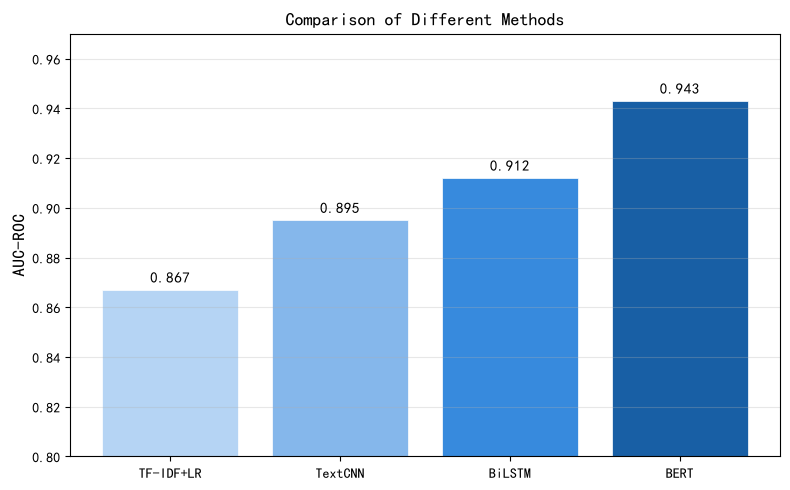

In [6]:
methods = ['TF-IDF+LR', 'TextCNN', 'BiLSTM', 'BERT']
auc_scores = [0.867, 0.895, 0.912, 0.943]
colors = ['#B5D4F4', '#85B7EB', '#378ADD', '#185FA5']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, auc_scores, color=colors, edgecolor='white', linewidth=0.5)
ax.set_ylim(0.80, 0.97)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('Comparison of Different Methods', fontsize=13)
ax.grid(axis='y', alpha=0.3)
for bar, score in zip(bars, auc_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{score:.3f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.savefig('method_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 4. ROC 曲线

ROC 曲线展示二分类模型在不同阈值下的真正率与假正率，AUC 值可作为整体性能的汇总指标。曲线越接近左上角，模型区分能力越强。

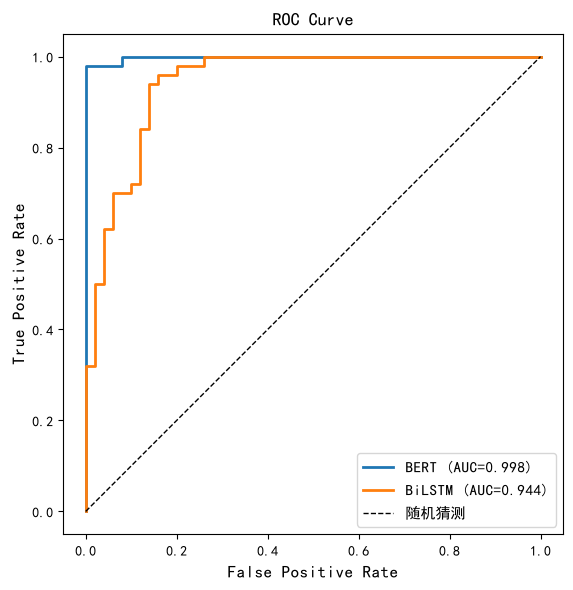

In [9]:
from sklearn.metrics import roc_curve, auc as calc_auc
import numpy as np

# ========== 构造模拟数据（后续有真实数据可直接替换） ==========
np.random.seed(42)
# 真实标签：共100个样本，正负样本各50个
y_true = np.concatenate([np.zeros(50), np.ones(50)])

# 模拟BERT模型的预测概率（性能更好，正负区分度更高）
bert_scores = np.concatenate([
    np.random.normal(0.2, 0.15, 50),  # 负样本预测值偏低
    np.random.normal(0.8, 0.15, 50)   # 正样本预测值偏高
])
# 模拟BiLSTM模型的预测概率（性能稍弱）
lstm_scores = np.concatenate([
    np.random.normal(0.3, 0.2, 50),
    np.random.normal(0.7, 0.2, 50)
])

# 将数值限制在0-1区间，符合概率定义
bert_scores = np.clip(bert_scores, 0, 1)
lstm_scores = np.clip(lstm_scores, 0, 1)

# ========== 绘制ROC曲线 ==========
fig, ax = plt.subplots(figsize=(6, 6))
for name, y_score in [('BERT', bert_scores), ('BiLSTM', lstm_scores)]:
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = calc_auc(fpr, tpr)
    ax.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={roc_auc:.3f})')

# 绘制随机猜测基准线
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='随机猜测')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve', fontsize=13)
ax.legend(fontsize=11)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 5. t-SNE 特征空间可视化

t-SNE 将高维特征降至二维，便于观察不同类别在特征空间中的聚类情况。类内紧凑、类间分离说明特征提取有效。

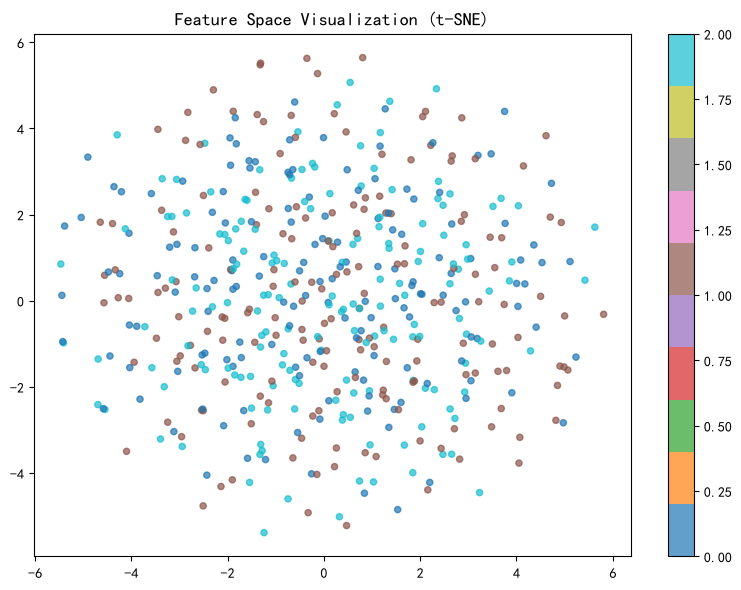

In [8]:
from sklearn.manifold import TSNE

features = np.random.randn(500, 128)   # 500个128维特征
labels_arr = np.random.randint(0, 3, 500)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(features)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels_arr,
                     cmap='tab10', alpha=0.7, s=20)
plt.colorbar(scatter)
ax.set_title('Feature Space Visualization (t-SNE)', fontsize=13)
plt.tight_layout()
plt.savefig('tsne.pdf', dpi=300, bbox_inches='tight')
plt.show()

## 小结

本 Notebook 使用模拟数据完成了五种论文级图表绘制，涵盖了训练过程监控、分类结果分析、模型对比、阈值评估和特征分布观察等典型科研场景。